In [12]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [15]:
import pandas as pd
import os
import sys
import pymc as pm
import pymc_bart as pmb
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [16]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

In [17]:
print(list(myPredictorsDf.columns))

['patientunitstayid', 'gender', 'age', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource', 'admissionweight', 'PEA', 'Asystole', 'VTachy', 'VFib', 'Hypothermia', 'FirstGCSTime', 'FirstGCS', 'LastGCSTime', 'LastGCS', 'FirstMGCSTime', 'FirstMGCS', 'LastMGCSTime', 'LastMGCS', 'Lactate', 'Troponin', 'pH', 'Chloride', 'hospitaldischargestatus', 'DeathAtDischarge', 'LastGCS15', 'GCS Total', 'Heart Rate', 'Non-Invasive BP Diastolic', 'Non-Invasive BP Mean', 'Non-Invasive BP Systolic', 'O2 Admin Device', 'O2 L/%', 'O2 Saturation', 'Respiratory Rate', 'Temperature (C)', 'Temperature (F)', 'Temperature Location', 'Value', 'Invasive BP Diastolic', 'Invasive BP Systolic', 'Pain Score', 'CI', 'PVR', 'Bedside Glucose', 'Eyes', 'Motor', 'Verbal', 'Invasive BP Mean', 'Delirium Scale', 'Delirium Score', 'Sedation Scale', 'Sedation Score', 'CPP', 'End Tidal CO2', 'ICP', 'CVP', 'CO', 'SVO2', 'SV', 'Pain Goal', 'Sedation Goal', 'Electrolyte Replacement', 'IAP', 'PR', 'QRS

In [18]:
myPredictorsDf.select_dtypes(include=['object']).columns

Index(['gender', 'apacheadmissiondx', 'hospitaladmittime24',
       'hospitaladmitsource', 'FirstGCS', 'LastGCS', 'hospitaldischargestatus',
       'GCS Total', 'O2 Admin Device', 'Temperature Location', 'Value',
       'Delirium Scale', 'Delirium Score', 'Sedation Scale',
       'Electrolyte Replacement', 'Fall Risk'],
      dtype='object')

In [19]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(int) == 6).astype(int)

In [20]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'Pressure Control', 'Vent Other', 'WBC's in peritoneal fluid',
       'Cyclosporin', 'Site', 'Amikacin - peak', 'PTT ratio',
       'Vancomycin - peak', 'LastGCSPositive', 'LastMGCSPositive'],
      dtype='object', length=230)

In [21]:
myXValue = myPredictorsDf.drop(columns= ['GCS Total', 'LastMGCSTime', 'FirstMGCSTime', 'Motor', 'LastMGCSPositive', 'LastMGCS', 'Sedation Scale', 'Electrolyte Replacement', 'Fall Risk', 'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale', 'Delirium Score', 'LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myYValue = myPredictorsDf[myFilter]['LastMGCSPositive']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastGCS15', 'Hypothermia']], test_size=0.3)

In [22]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_pre = myPipeline.fit_transform(X_train)
X_test_pre = myPipeline.transform(X_test)
with pm.Model() as model:
    X_shared = pm.MutableData('X_shared', X_train_pre)
    y_shared = pm.MutableData('y_shared', y_train)
    u = pmb.BART('u', X = X_shared, Y= y_train, m=30)
    p = 1 / (1 + np.exp(-u))
    y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
    trace = pm.sample(50, return_inferencedata=True)
    # trace = az.from_netcdf('bart_model_tracedc.nc')
# Save trace 
# az.to_netcdf(trace, 'bart_model_tracedc.nc')

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [u]


Sampling 4 chains for 1_000 tune and 50 draw iterations (4_000 + 200 draws total) took 29 seconds.
The number of samples is too small to check convergence reliably.


NameError: name 'az' is not defined

In [23]:
import arviz as az
az.to_netcdf(trace, 'bart_model_tracedc.nc')

'bart_model_tracedc.nc'

In [24]:
with model:
    pm.set_data({'X_shared': X_train_pre, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


ROC AUC: 0.77
Accuracy: 0.71


In [25]:
with model:
    pm.set_data({'X_shared': X_test_pre, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [u, y_obs]


ROC AUC: 0.74
Accuracy: 0.69


In [33]:
myXValueModified1 = X_test.copy()
myXValueModified1['Hypothermia'] = 1.0
myXValueModified2 = X_test.copy()
myXValueModified2['Hypothermia'] = 0.0
with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



Sampling: [u, y_obs]


Sampling: [u, y_obs]


In [43]:
def getTreatmentEffectDiff(X_train, y_train, myNewDf, aCategory = 'CPC12'):
    myData = pd.concat([X_train['Hypothermia'], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + Hypothermia',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * Hypothermia',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    return p_value

def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')
    return lower_third, upper_third, myNewDf


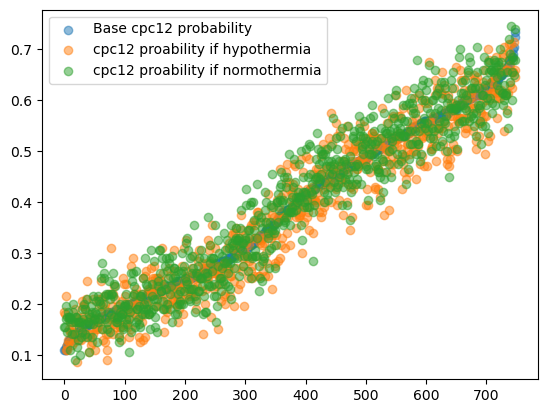

In [44]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()
myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


In [45]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = myYPred

Optimization terminated successfully.
         Current function value: 0.642601
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.641781
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.8372422778993496
p-value: 0.6579534209780153
Degress of freedom: 2.0


0.6579534209780153

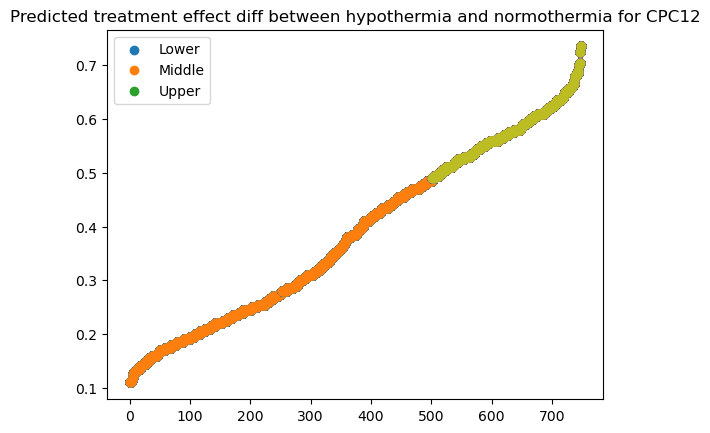

In [46]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf)
getTreatmentEffectDiff(myXValue, myYValue, myNewDf, 'LastMGCSPositive')